In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Install dependencies
!pip install ultralytics -q

# Parking Space Detection — Model Development


---
## Prepare environment

In [17]:
import os
import json
import yaml
import shutil
import torch
import numpy as np
import pandas as pd
import glob, random, math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from ultralytics import YOLO
from PIL import Image

In [14]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## Paths & Constants


In [ ]:
# Paths (must match data_preparation.ipynb)
SPLIT_BASE  = "/content/data/dataset_split"
DATA_YAML   = os.path.join(SPLIT_BASE, "data.yaml")

# Training hyperparameters
IMG_SIZE    = 640 # resize to 640x640 (original images: 1280x720)
BATCH       = 16

In [16]:
# Check file existence
print(f"data.yaml exists: {os.path.exists(DATA_YAML)}")

data.yaml exists: True


## Iteration 1 — Baseline: YOLOv8n (No Augmentation)

In [ ]:
model_v8_base = YOLO("yolov8n.pt")

results_v8_base = model_v8_base.train(
    data      = DATA_YAML,
    epochs    = 15,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    project   = "/content//runs/detect",
    name      = "v8n_baseline",
    augment   = False, # no augmentation
    device    = device,
    verbose   = True,
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/dataset_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8n_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

In [18]:
# Evaluate baseline on test set
best_v8_base = "/content/runs/detect/v8n_baseline/weights/best.pt"
eval_model   = YOLO(best_v8_base)

metrics_v8_base = eval_model.val(
    data   = DATA_YAML,
    split  = "test",
    imgsz  = IMG_SIZE,
    batch  = BATCH,
    project= "/content/runs/detect",
    name   = "v8n_baseline_test",
)

print("\n── Baseline (YOLOv8n) Test Results ──")
print(f"  mAP50      : {metrics_v8_base.box.map50:.4f}")
print(f"  mAP50-95   : {metrics_v8_base.box.map:.4f}")
print(f"  Precision  : {metrics_v8_base.box.mp:.4f}")
print(f"  Recall     : {metrics_v8_base.box.mr:.4f}")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2745.2±601.9 MB/s, size: 282.1 KB)
val: Scanning /content/data/dataset_split/test/labels... 2076 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2076/2076 1.1Kit/s 2.0s
val: New cache created: /content/data/dataset_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 6.9it/s 18.9s
                   all       2076      82914      0.293      0.244      0.147     0.0342
                 empty       1560      34922       0.25      0.239      0.158     0.0381
              occupied       1689      47992      0.337      0.249      0.136     0.0302
Speed: 0.5ms preprocess, 2.0ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/v8n_baseline_test

── Basel

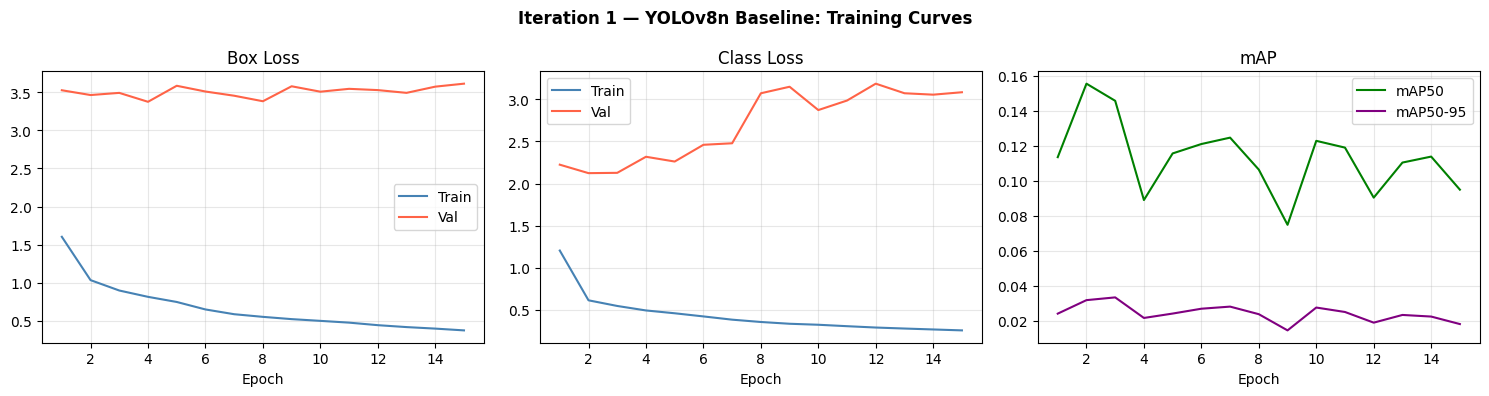

In [19]:
# Plot training curves — baseline
csv_path = Path("/content/runs/detect/v8n_baseline/results.csv")
df_base  = pd.read_csv(csv_path)
df_base.columns = df_base.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Iteration 1 — YOLOv8n Baseline: Training Curves", fontweight="bold")

axes[0].plot(df_base["epoch"], df_base["train/box_loss"], label="Train", color="steelblue")
axes[0].plot(df_base["epoch"], df_base["val/box_loss"],   label="Val",   color="tomato")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_base["epoch"], df_base["train/cls_loss"], label="Train", color="steelblue")
axes[1].plot(df_base["epoch"], df_base["val/cls_loss"],   label="Val",   color="tomato")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(df_base["epoch"], df_base["metrics/mAP50(B)"],   label="mAP50",    color="green")
axes[2].plot(df_base["epoch"], df_base["metrics/mAP50-95(B)"], label="mAP50-95", color="purple")
axes[2].set_title("mAP"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/baseline_training_curves.png", dpi=150)
plt.show()

---
## Iteration 2 — YOLOv8n + Augmentation

**Problem from Iteration 1:** Severe overfitting with a widening train-val gap on Box Loss, combined with domain generalization failure on the unseen test lot (mAP50 = 0.1472, Precision = 0.2934).

**Fix:**
- `augment=True` — expose model to lighting/viewpoint variation (fixes domain generalization)
- `dropout=0.2` + `weight_decay=0.0005` — penalize memorization (fixes overfitting)
- `lr0=0.005` + `warmup_epochs=5` — smoother convergence (fixes oscillation)
- `box=7.5` — emphasize localization (fixes mAP50-95 = 0.02–0.03 in Iter 1)
- `epochs=50` + `patience=20` — longer training budget

In [ ]:
model_v8_aug = YOLO("yolov8n.pt")

results_v8_aug = model_v8_aug.train(
    data      = DATA_YAML,
    epochs    = 50,              #change from 15
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    project   = "/content/runs/detect",
    name      = "v8n_aug",
    augment   = True,            #augmentation (fixes domain generalization)
    device    = device,
    verbose   = True,

    # Regularization (fixes overfitting)
    dropout   = 0.2,             # dropout in classifier head
    weight_decay = 0.0005,       # L2 penalty — shrinks train-val gap
    patience     = 20,           # early stopping: stop if val mAP stalls

    # LR: smoother convergence (fixes oscillation)
    lr0       = 0.005,           # lower than default 0.01
    warmup_epochs = 5,           # stable early training

    # Box loss weight: fixes mAP50-95 drop
    box       = 7.5,             # emphasize localization accuracy
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/dataset_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8n_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [20]:
best_v8_aug = "/content/runs/detect/v8n_aug/weights/best.pt"
eval_model  = YOLO(best_v8_aug)

metrics_v8_aug = eval_model.val(
    data  = DATA_YAML,
    split = "test",
    imgsz = IMG_SIZE,
    batch = BATCH,
    project= "/content/runs/detect",
    name  = "v8n_aug_test",
)

print("\n── YOLOv8n + Augmentation Test Results ──")
print(f"  mAP50      : {metrics_v8_aug.box.map50:.4f}")
print(f"  mAP50-95   : {metrics_v8_aug.box.map:.4f}")
print(f"  Precision  : {metrics_v8_aug.box.mp:.4f}")
print(f"  Recall     : {metrics_v8_aug.box.mr:.4f}")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3770.8±627.7 MB/s, size: 256.0 KB)
val: Scanning /content/data/dataset_split/test/labels.cache... 2076 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2076/2076 669.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 6.7it/s 19.4s
                   all       2076      82914      0.333      0.321      0.186     0.0417
                 empty       1560      34922      0.324      0.344      0.188      0.042
              occupied       1689      47992      0.341      0.297      0.185     0.0415
Speed: 0.5ms preprocess, 2.1ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/v8n_aug_test

── YOLOv8n + Augmentation Test Results ──
  mAP50      : 0.1864
  mAP50-95 

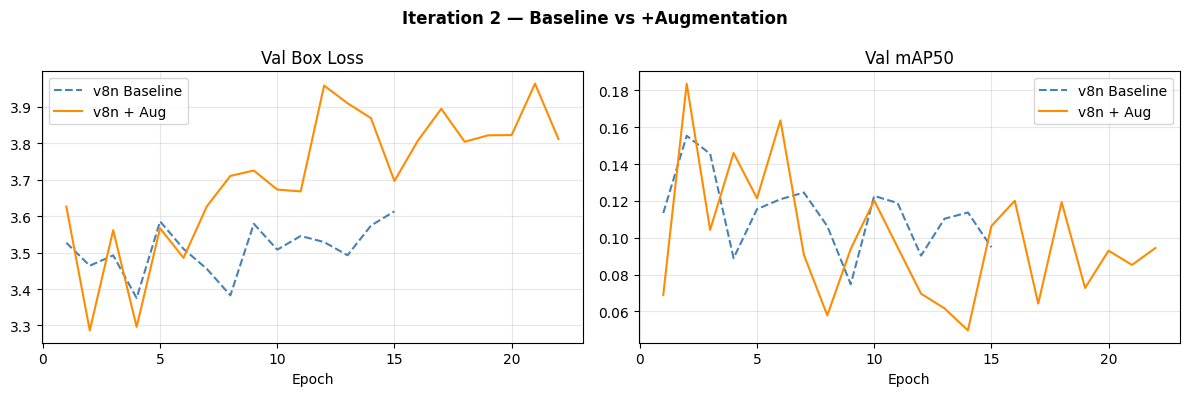

In [21]:
# Compare baseline vs augmented — learning curves
csv_aug = Path("/content/runs/detect/v8n_aug/results.csv")
df_aug  = pd.read_csv(csv_aug)
df_aug.columns = df_aug.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Iteration 2 — Baseline vs +Augmentation", fontweight="bold")

# Val loss comparison
axes[0].plot(df_base["epoch"], df_base["val/box_loss"], label="v8n Baseline",  color="steelblue",  linestyle="--")
axes[0].plot(df_aug["epoch"],  df_aug["val/box_loss"],  label="v8n + Aug",     color="darkorange")
axes[0].set_title("Val Box Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

# mAP50 comparison
axes[1].plot(df_base["epoch"], df_base["metrics/mAP50(B)"], label="v8n Baseline", color="steelblue",  linestyle="--")
axes[1].plot(df_aug["epoch"],  df_aug["metrics/mAP50(B)"],  label="v8n + Aug",    color="darkorange")
axes[1].set_title("Val mAP50"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/iter2_comparison.png", dpi=150)
plt.show()

---
## Iteration 3 — YOLOv8n + Augmentation (Tuned)

**Problem from Iteration 2:** mAP50 peaked at epoch 2 then collapsed. This usually means the learning rate was too high. Also, using full Mosaic (1.0) made the data too random, so YOLOv8n couldn’t stay stable.

**Fix:**
- `lr0=0.003` — smaller gradient steps reduce early spike
- `mosaic=0.5` — halved mosaic probability reduces composition difficulty
- `warmup_epochs=8` — longer warm-up before full LR kicks in
- `dropout=0.1`  — less regularization to avoid underfitting
- `patience=30` — larger budget to recover from slow start


In [ ]:
model_v8_aug_2 = YOLO("yolov8n.pt")

results_v8_aug_2 = model_v8_aug_2.train(
    data      = DATA_YAML,
    epochs    = 50,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    project   = "/content/runs/detect",
    name      = "v8n_aug_2",
    device    = device,
    verbose   = True,
    augment   = True,
    mosaic    = 0.5,
    dropout   = 0.1,
    weight_decay = 0.0005,
    patience     = 30,
    lr0       = 0.003,
    warmup_epochs = 8,
    box       = 7.5,
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/dataset_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=v8n_aug_2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [22]:
best_v8_aug_2 = "/content/runs/detect/v8n_aug_2/weights/best.pt"
eval_model    = YOLO(best_v8_aug_2)

metrics_v8_aug_2 = eval_model.val(
    data   = DATA_YAML,
    split  = "test",
    imgsz  = IMG_SIZE,
    batch  = BATCH,
    project= "/content/runs/detect",
    name   = "v8n_aug_2_test",
)

print("\n── YOLOv8n + Aug (Tuned) Test Results ──")
print(f"  mAP50      : {metrics_v8_aug_2.box.map50:.4f}")
print(f"  mAP50-95   : {metrics_v8_aug_2.box.map:.4f}")
print(f"  Precision  : {metrics_v8_aug_2.box.mp:.4f}")
print(f"  Recall     : {metrics_v8_aug_2.box.mr:.4f}")


Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4466.1±1205.2 MB/s, size: 235.2 KB)
val: Scanning /content/data/dataset_split/test/labels.cache... 2076 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2076/2076 580.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 6.6it/s 19.7s
                   all       2076      82914      0.315      0.321      0.197     0.0456
                 empty       1560      34922      0.277      0.283      0.188     0.0448
              occupied       1689      47992      0.353      0.359      0.206     0.0464
Speed: 0.5ms preprocess, 2.1ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/v8n_aug_2_test

── YOLOv8n + Aug (Tuned) Test Results ──
  mAP50      : 0.1968
  mAP50-9

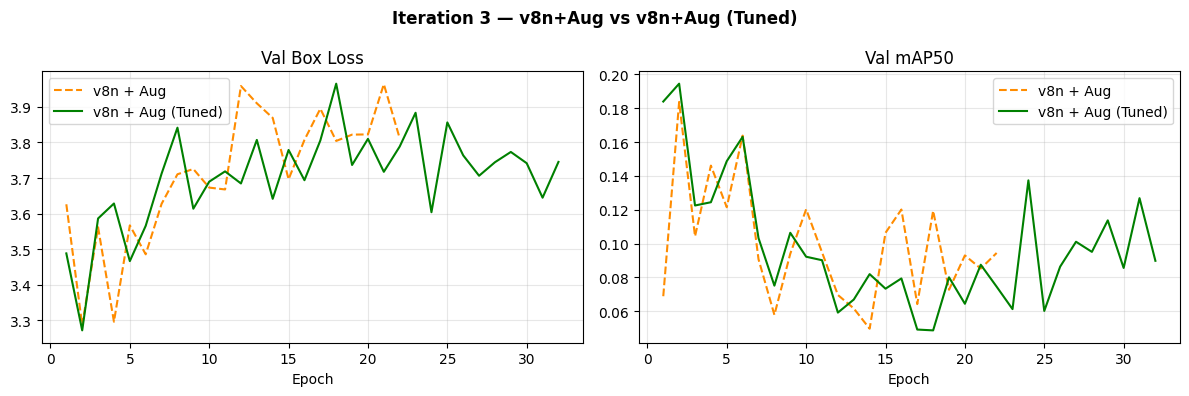

In [23]:
# Compare v8n+Aug vs v8n+Aug (Tuned) — learning curves
csv_aug_2 = Path("/content/runs/detect/v8n_aug_2/results.csv")
df_aug_2  = pd.read_csv(csv_aug_2)
df_aug_2.columns = df_aug_2.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Iteration 3 — v8n+Aug vs v8n+Aug (Tuned)", fontweight="bold")

axes[0].plot(df_aug["epoch"],   df_aug["val/box_loss"],   label="v8n + Aug",        color="darkorange", linestyle="--")
axes[0].plot(df_aug_2["epoch"], df_aug_2["val/box_loss"], label="v8n + Aug (Tuned)", color="green")
axes[0].set_title("Val Box Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_aug["epoch"],   df_aug["metrics/mAP50(B)"],   label="v8n + Aug",        color="darkorange", linestyle="--")
axes[1].plot(df_aug_2["epoch"], df_aug_2["metrics/mAP50(B)"], label="v8n + Aug (Tuned)", color="green")
axes[1].set_title("Val mAP50"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/iter3_comparison.png", dpi=150)
plt.show()

---
## Performance Comparison

In [24]:
# Collect all metrics into a summary table
summary = {
    "Model": [
        "1. YOLOv8n (baseline)",
        "2. YOLOv8n + Aug",
        "3. YOLOv8n + Aug (Tuned)",
    ],
    "mAP50": [
        round(metrics_v8_base.box.map50,  4),
        round(metrics_v8_aug.box.map50,   4),
        round(metrics_v8_aug_2.box.map50, 4),
    ],
    "mAP50-95": [
        round(metrics_v8_base.box.map,    4),
        round(metrics_v8_aug.box.map,     4),
        round(metrics_v8_aug_2.box.map,   4),
    ],
    "Precision": [
        round(metrics_v8_base.box.mp,     4),
        round(metrics_v8_aug.box.mp,      4),
        round(metrics_v8_aug_2.box.mp,    4),
    ],
    "Recall": [
        round(metrics_v8_base.box.mr,     4),
        round(metrics_v8_aug.box.mr,      4),
        round(metrics_v8_aug_2.box.mr,    4),
    ],
}

df_summary = pd.DataFrame(summary)
df_summary.set_index("Model", inplace=True)
print("\n── All Models: Test Set Performance ──")
print(df_summary.to_string())
df_summary.to_csv("/content/model_comparison.csv")



── All Models: Test Set Performance ──
                           mAP50  mAP50-95  Precision  Recall
Model                                                        
1. YOLOv8n (baseline)     0.1472    0.0342     0.2934  0.2437
2. YOLOv8n + Aug          0.1864    0.0417     0.3325  0.3209
3. YOLOv8n + Aug (Tuned)  0.1968    0.0456     0.3150  0.3213


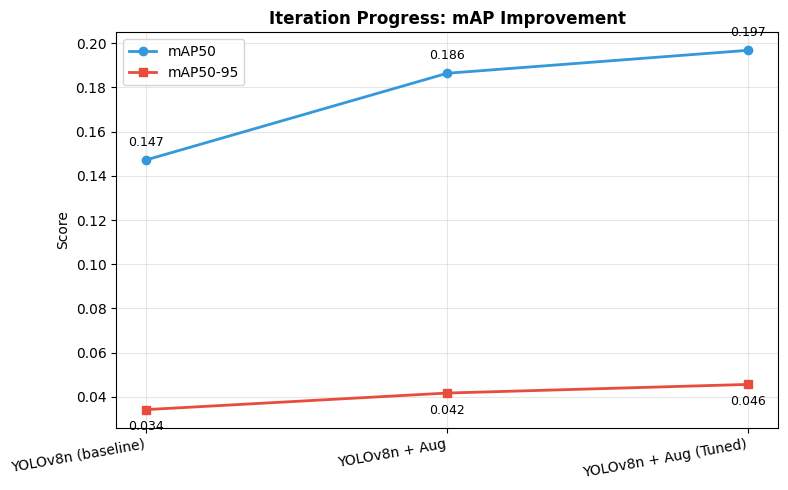

In [25]:
# mAP50 progression line chart: shows improvement per iteration
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(1, 4), df_summary["mAP50"].values,    marker="o", label="mAP50",    color="#3498DB", linewidth=2)
ax.plot(range(1, 4), df_summary["mAP50-95"].values, marker="s", label="mAP50-95", color="#E74C3C", linewidth=2)

ax.set_xticks(range(1, 4))
ax.set_xticklabels([m.split(". ", 1)[1].strip() for m in df_summary.index.tolist()], rotation=10, ha="right")
ax.set_ylabel("Score")
ax.set_title("Iteration Progress: mAP Improvement", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

for i, (m50, m5095) in enumerate(zip(df_summary["mAP50"], df_summary["mAP50-95"])):
    ax.annotate(f"{m50:.3f}",   (i+1, m50),   textcoords="offset points", xytext=(0, 10),  ha="center", fontsize=9)
    ax.annotate(f"{m5095:.3f}", (i+1, m5095), textcoords="offset points", xytext=(0, -15), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/iteration_progress.png", dpi=150)
plt.show()

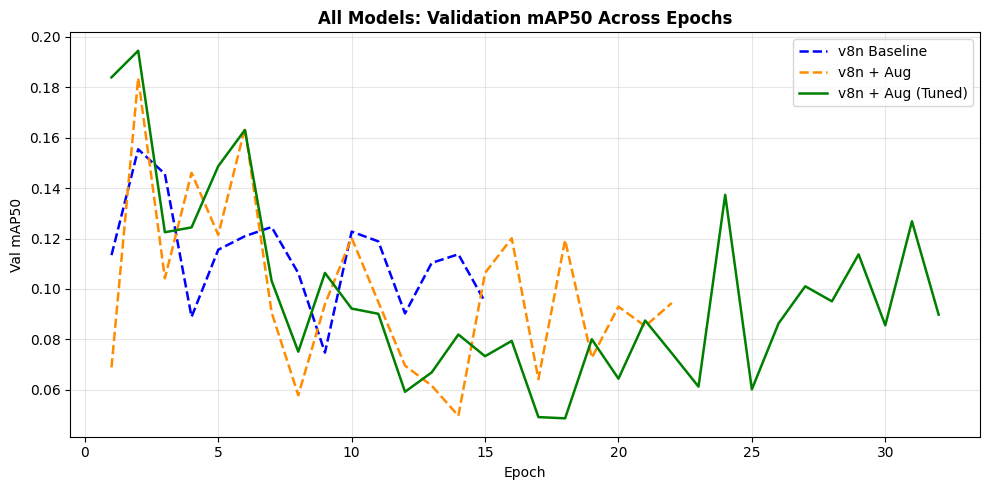

In [26]:
# All 3 models: mAP50 learning curves on val set
dfs = {
    "v8n Baseline": (df_base,  "blue",       "--"),
    "v8n + Aug": (df_aug,   "darkorange",  "--"),
    "v8n + Aug (Tuned)": (df_aug_2, "green",       "-"),
}

fig, ax = plt.subplots(figsize=(10, 5))

for label, (df_i, color, ls) in dfs.items():
    ax.plot(df_i["epoch"], df_i["metrics/mAP50(B)"], label=label, color=color, linestyle=ls, linewidth=1.8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Val mAP50")
ax.set_title("All Models: Validation mAP50 Across Epochs", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/all_models_mAP_curves.png", dpi=150)
plt.show()


### Confusion Matrix Comparison


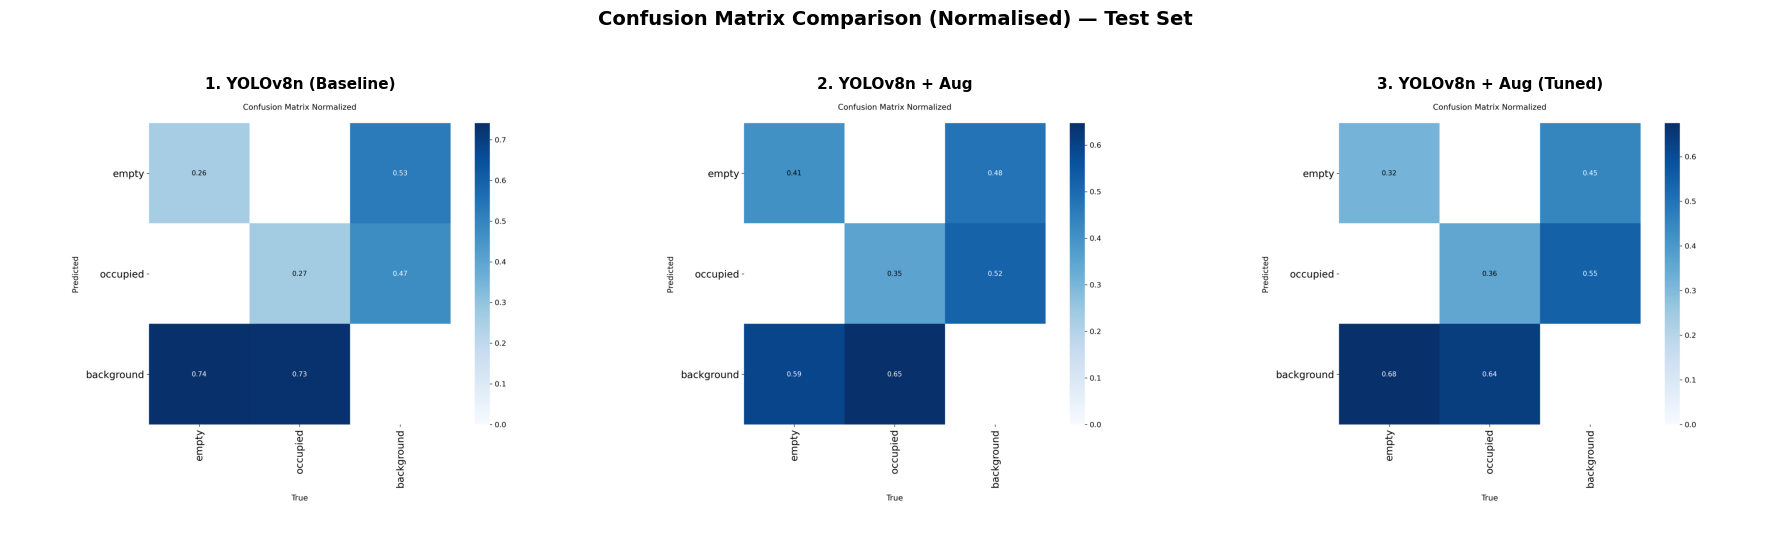

In [28]:
cm_paths = {
    "1. YOLOv8n (Baseline)"      : "/content/runs/detect/v8n_baseline_test/confusion_matrix_normalized.png",
    "2. YOLOv8n + Aug"           : "/content/runs/detect/v8n_aug_test/confusion_matrix_normalized.png",
    "3. YOLOv8n + Aug (Tuned)"   : "/content/runs/detect/v8n_aug_2_test/confusion_matrix_normalized.png",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Confusion Matrix Comparison (Normalised) — Test Set", fontweight="bold", fontsize=14)

for ax, (title, path) in zip(axes, cm_paths.items()):
    if os.path.exists(path):
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(title, fontsize=11, fontweight="bold")
    else:
        ax.text(0.5, 0.5, f"File not found:\n{path}",
                ha="center", va="center", transform=ax.transAxes, color="red", fontsize=9)
        ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Confusion Matrix Analysis

- All three models show high miss rate, indicating missed detections caused by domain shift from the unseen test lot (UFPR05).
- Iteration 2 performs best on `empty` detection (TP: 0.41, FN: 0.59).
- Iteration 3 performs best on `occupied` detection (TP: 0.36, FN: 0.64) with
the lowest false alarms on `empty` (FP: 0.45).

---
## Model Selection

### Overfitting / Underfitting Analysis

In [37]:
# Overfitting gap analysis: Train loss vs Val loss at final epoch for all models
model_names = ["v8n Baseline", "v8n + Aug", "v8n + Aug (Tuned)"]
all_dfs     = [df_base, df_aug, df_aug_2]

print("── Train vs Val Box Loss at Final Epoch ──")
print(f"{'Model':<22} {'Train Loss':>12} {'Val Loss':>12} {'Gap':>10}")
print("-" * 60)

for name, df_i in zip(model_names, all_dfs):
    train_loss = df_i["train/box_loss"].iloc[-1]
    val_loss   = df_i["val/box_loss"].iloc[-1]
    gap        = val_loss - train_loss
    print(f"{name:<22} {train_loss:>12.4f} {val_loss:>12.4f} {gap:>10.4f}")

── Train vs Val Box Loss at Final Epoch ──
Model                    Train Loss     Val Loss        Gap
------------------------------------------------------------
v8n Baseline                 0.3738       3.6134     3.2397
v8n + Aug                    0.4791       3.8117     3.3327
v8n + Aug (Tuned)            0.4024       3.7454     3.3430


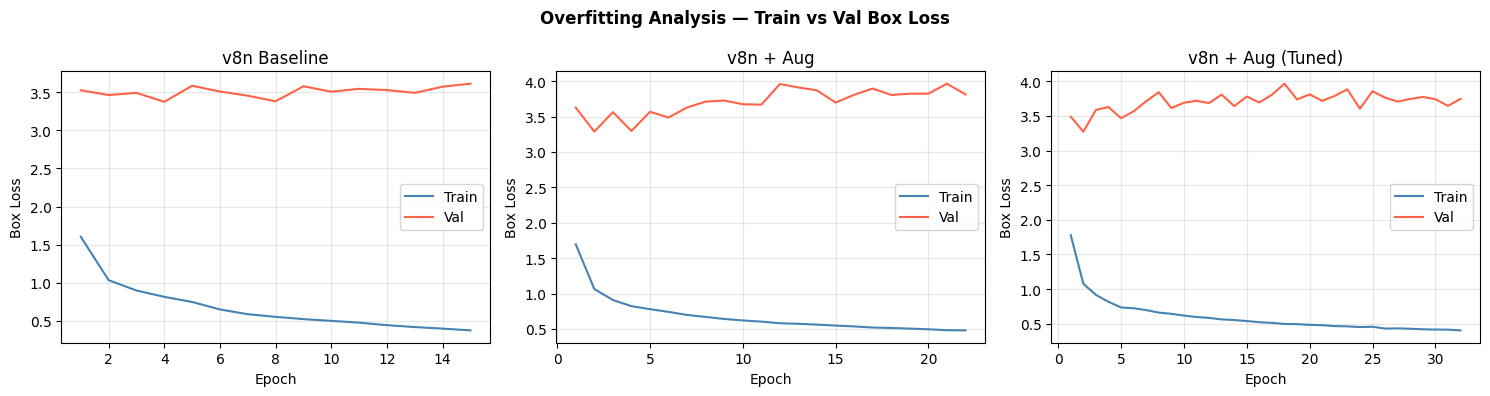

In [39]:
# Overfitting plot — train vs val loss for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Overfitting Analysis — Train vs Val Box Loss", fontweight="bold")

for ax, name, df_i in zip(axes, model_names, all_dfs):
    ax.plot(df_i["epoch"], df_i["train/box_loss"], label="Train", color="steelblue")
    ax.plot(df_i["epoch"], df_i["val/box_loss"],   label="Val",   color="tomato")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Box Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/overfitting_analysis.png", dpi=150)
plt.show()

**Summary:** All three models show severe overfitting → val loss remains flat regardless of augmentation or tuning, while train loss continues to drop. The gap is nearly identical across all variants, confirming this is a domain shift issue from evaluating on a completely unseen parking environment, not an optimization problem that augmentation or LR tuning alone can fix.


### Final Model Justification

**Selected model: YOLOv8n + Augmentation (Tuned)**

- **Best metrics** → Highest mAP50 (0.197) and mAP50-95 (0.046) across all iterations.
- **Most stable training** → Val mAP50 no longer collapses after epoch 2.
- **Best per-class detection** → Highest TP for `occupied` (0.36), lowest FN (0.64).

## Visualise predictions on test images

In [32]:
# Use best model from Iter 3
best_model_path = "/content/runs/detect/v8n_aug_2/weights/best.pt"
viz_model = YOLO(best_model_path)

test_img_dir = os.path.join(SPLIT_BASE, "test", "images")
test_images  = sorted(glob.glob(os.path.join(test_img_dir, "*.jpg"))
                    + glob.glob(os.path.join(test_img_dir, "*.png")))

print(f"Found {len(test_images)} test images in {test_img_dir}")
assert len(test_images) > 0, f"No images found — check path: {test_img_dir}"

# Sample up to 12
random.seed(42)
sample_imgs = random.sample(test_images, min(12, len(test_images)))
n_samples   = len(sample_imgs)

# Predict one-by-one to avoid numpy stack error on mixed sizes
results_list = [viz_model.predict(source=img, imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
                for img in sample_imgs]

# Plot grid
n_cols = 4
n_rows = math.ceil(n_samples / n_cols)
CLASS_COLORS = {"empty": "#2ECC71", "occupied": "#E74C3C"}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
fig.suptitle("Final Model Predictions on Test Set (YOLOv8n + Aug Tuned)", fontweight="bold", fontsize=14)

for ax, result in zip(axes, results_list):
    img = result.orig_img[:, :, ::-1]
    ax.imshow(img)
    ax.axis("off")

    n_empty, n_occupied = 0, 0
    if result.boxes is not None and len(result.boxes):
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf  = float(box.conf[0])
            cls   = int(box.cls[0])
            label = result.names[cls]
            color = CLASS_COLORS.get(label, "yellow")
            if label == "empty": n_empty    += 1
            else:                 n_occupied += 1

            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1-4, f"{label} {conf:.2f}",
                    color="white", fontsize=6, fontweight="bold",
                    bbox=dict(facecolor=color, edgecolor="none", pad=1))

    ax.set_title(f"empty:{n_empty}  occupied:{n_occupied}", fontsize=8)

for ax in axes[n_samples:]:
    ax.axis("off")

empty_patch    = mpatches.Patch(color="#2ECC71", label="Empty")
occupied_patch = mpatches.Patch(color="#E74C3C", label="Occupied")
fig.legend(handles=[empty_patch, occupied_patch], loc="lower center",
           ncol=2, fontsize=11, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("/content/test_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Save Final Model

In [ ]:
# Save Final Model 
BASE_DIR     = "/content/drive/MyDrive"
FINAL_DIR    = os.path.join(BASE_DIR, "final_model_results") 
COMPARE_DIR  = os.path.join(BASE_DIR, "outputs", "comparison") 

os.makedirs(FINAL_DIR,   exist_ok=True)
os.makedirs(COMPARE_DIR, exist_ok=True)

shutil.copy(best_v8_aug_2, os.path.join(FINAL_DIR, "best.pt"))

run_dir = "/content/runs/detect/v8n_aug_2"
for fname in ["results.csv", "results.png",
              "confusion_matrix.png", "confusion_matrix_normalized.png"]:
    src = os.path.join(run_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, FINAL_DIR)

for plot in ["iter3_comparison.png", "test_predictions.png"]:
    src = f"/content/{plot}"
    if os.path.exists(src):
        shutil.copy(src, os.path.join(BASE_DIR, "outputs", "predictions") if plot == "test_predictions.png" else COMPARE_DIR)

for plot in ["baseline_training_curves.png", "iter2_comparison.png",
             "iteration_progress.png", "all_models_mAP_curves.png",
             "confusion_matrix_comparison.png","model_comparison.csv"]:
    src = f"/content/{plot}"
    if os.path.exists(src):
        shutil.copy(src, COMPARE_DIR)

ANALYSIS_DIR = os.path.join(BASE_DIR, "outputs", "analysis")
os.makedirs(ANALYSIS_DIR, exist_ok=True)

for plot in ["overfitting_analysis.png"]:
    src = f"/content/{plot}"
    if os.path.exists(src):
        shutil.copy(src, ANALYSIS_DIR)